In [1]:
import pandas as pd
import statsmodels.api as sm
import numpy as np
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from sklearn.linear_model import LinearRegression

In [2]:
spc = pd.read_csv(r"C:\Users\Username\OneDrive\Desktop\Invesco_project\data\^GSPC_mon.csv")
spe = pd.read_csv(r"C:\Users\Username\OneDrive\Desktop\Invesco_project\data\RSP_mon.csv", nrows =239)

In [3]:
spc["Date"] = pd.to_datetime(spc["Date"])
spe["Date"] = pd.to_datetime(spe["Date"])

In [4]:
spc.set_index("Date", inplace=True)
spe.set_index("Date", inplace=True)

In [8]:
spc

,Close,High,Low,Open,Volume
Date,,,,,
1985-01-01,179.630005,180.270004,163.360001,167.199997,2.673710e+09
1985-02-01,181.179993,183.949997,177.750000,179.630005,2.194620e+09
1985-03-01,180.660004,183.889999,176.529999,181.179993,2.153090e+09
1985-04-01,179.830002,183.610001,177.860001,180.660004,1.981880e+09
1985-05-01,189.550003,189.979996,178.350006,179.830002,2.350340e+09
...,...,...,...,...,...
2025-01-01,6040.529785,6128.180176,5773.310059,5903.259766,8.863938e+10
2025-02-01,5954.500000,6147.430176,5837.660156,5969.649902,9.231700e+10
2025-03-01,5611.850098,5986.089844,5488.729980,5968.330078,1.113870e+11


In [9]:
spc.index = spc.index + pd.tseries.offsets.MonthEnd(0)

spc['mkt_ret'] = spc['Close'].pct_change()
mkt_ret = spc[['mkt_ret']].dropna().copy()

mkt_ret

,mkt_ret
Date,
1985-02-28,0.008629
1985-03-31,-0.002870
1985-04-30,-0.004594
1985-05-31,0.054051
1985-06-30,0.012134
...,...
2025-01-31,0.027016
2025-02-28,-0.014242
2025-03-31,-0.057545


In [7]:
sp = pd.read_csv(r"C:\Users\Username\OneDrive\Desktop\Invesco_project\sp500_returns_with_tickers.csv")
sp

,date,ACF,ABK,AMT,JAVA,AN,ORCL,MSFT,SDS,AYE,...,CFN,AVGO,VRSK,DG.2,FTNT,VAL,GNRC,QEP,CBOE,TSLA
0,1960-01-29,0.005155,-0.015000,-0.020785,NaN,-0.092262,NaN,NaN,NaN,-0.020833,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1960-02-29,0.046154,0.017767,0.009434,NaN,-0.021312,NaN,NaN,NaN,0.053192,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1960-03-31,-0.059553,-0.100249,-0.047170,NaN,0.038851,NaN,NaN,NaN,-0.005387,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1960-04-29,-0.081794,-0.056180,0.000000,NaN,-0.050407,NaN,NaN,NaN,0.010274,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1960-05-31,0.048851,-0.029762,-0.034654,NaN,0.029110,NaN,NaN,NaN,0.044068,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
775,2024-08-30,NaN,NaN,NaN,NaN,NaN,0.013195,-0.001100,NaN,NaN,...,NaN,0.013319,0.042292,-0.310823,0.321675,NaN,0.005460,NaN,0.122718,-0.077391
776,2024-09-30,NaN,NaN,NaN,NaN,NaN,0.206030,0.031548,NaN,NaN,...,NaN,0.062707,-0.016385,0.019284,0.010950,NaN,0.015013,NaN,-0.002580,0.221942
777,2024-10-31,NaN,NaN,NaN,NaN,NaN,-0.012676,-0.055659,NaN,NaN,...,NaN,-0.015826,0.025228,-0.046589,0.014313,NaN,0.041981,NaN,0.042466,-0.045025
778,2024-11-29,NaN,NaN,NaN,NaN,NaN,0.101287,0.044149,NaN,NaN,...,NaN,-0.045297,0.070945,-0.034608,0.208365,NaN,0.136817,NaN,0.013626,0.381469


In [10]:
sp['date'] = pd.to_datetime(sp['date'])
sp.set_index('date', inplace=True)

In [12]:
data = sp.join(mkt_ret, how='inner')
data

,ACF,ABK,AMT,JAVA,AN,ORCL,MSFT,SDS,AYE,TROW,...,AVGO,VRSK,DG.2,FTNT,VAL,GNRC,QEP,CBOE,TSLA,mkt_ret
1985-02-28,NaN,NaN,-0.013423,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.008629
1985-04-30,NaN,NaN,-0.058065,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.004594
1985-05-31,NaN,NaN,-0.008621,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.054051
1985-07-31,NaN,NaN,-0.060741,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.004848
1985-09-30,NaN,NaN,-0.079646,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.034724
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-05-31,NaN,NaN,NaN,NaN,NaN,0.030242,0.068194,NaN,NaN,0.075386,...,0.021749,0.159754,-0.016381,-0.061095,NaN,0.082745,NaN,-0.042009,-0.028372,0.048021
2024-07-31,NaN,NaN,NaN,NaN,NaN,-0.009561,-0.063989,NaN,NaN,-0.009539,...,0.000791,-0.028937,-0.085079,-0.037000,NaN,0.177431,NaN,0.079090,0.172781,0.011321
2024-09-30,NaN,NaN,NaN,NaN,NaN,0.206030,0.031548,NaN,NaN,0.038948,...,0.062707,-0.016385,0.019284,0.010950,NaN,0.015013,NaN,-0.002580,0.221942,0.020197
2024-10-31,NaN,NaN,NaN,NaN,NaN,-0.012676,-0.055659,NaN,NaN,0.008538,...,-0.015826,0.025228,-0.046589,0.014313,NaN,0.041981,NaN,0.042466,-0.045025,-0.009897


## Window 12

In [13]:
window = 12
min_obs = 12  

dates = data.index
tickers = data.columns.drop("mkt_ret")
beta_dict = {}
vol_dict = {}

for i in range(window, len(dates)):
    current_date = dates[i]
    window_data = data.iloc[i-window:i]
    
    betas = {}
    volas = {}
    
    for ticker in tickers:
        temp = window_data[[ticker, 'mkt_ret']].dropna()
        if len(temp) >= min_obs:
            X = temp['mkt_ret'].values.reshape(-1, 1)
            y = temp[ticker].values
            beta = np.linalg.lstsq(X, y, rcond=None)[0][0]
            sigma = y.std()
            betas[ticker] = beta
            volas[ticker] = sigma
            
    beta_dict[current_date] = betas
    vol_dict[current_date] = volas


In [14]:
beta_df = pd.DataFrame(beta_dict).T.sort_index()
vol_df = pd.DataFrame(vol_dict).T.sort_index()

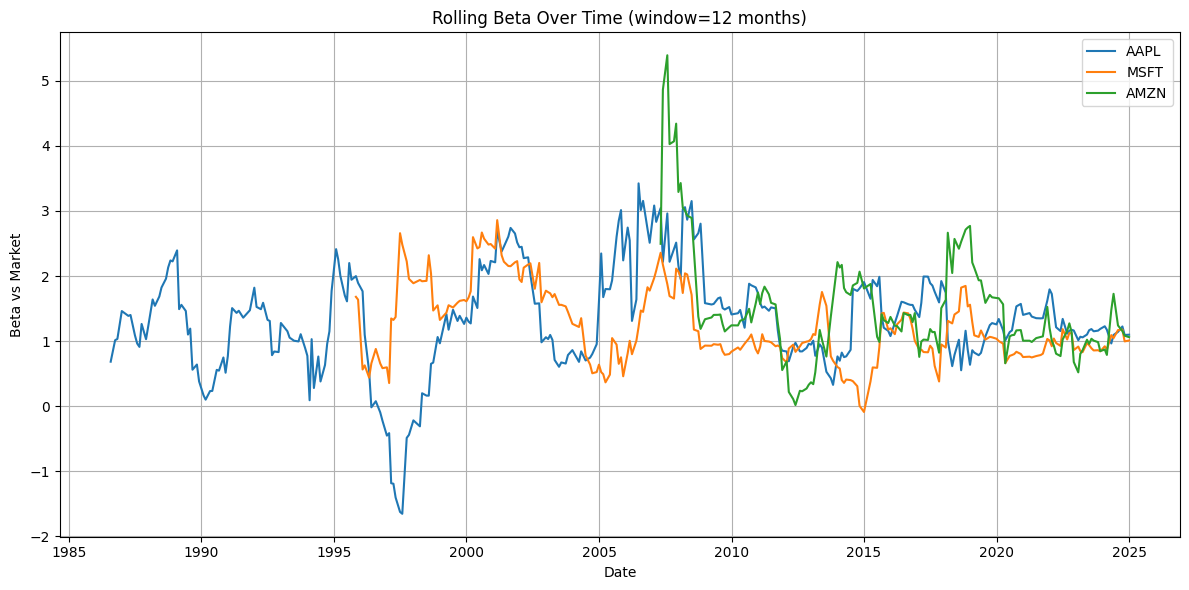

In [15]:
sample_tickers = ['AAPL', 'MSFT', 'AMZN']

plt.figure(figsize=(12, 6))
for ticker in sample_tickers:
    if ticker in beta_df.columns:
        plt.plot(beta_df.index, beta_df[ticker], label=ticker)

plt.title("Rolling Beta Over Time (window=12 months)")
plt.xlabel("Date")
plt.ylabel("Beta vs Market")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

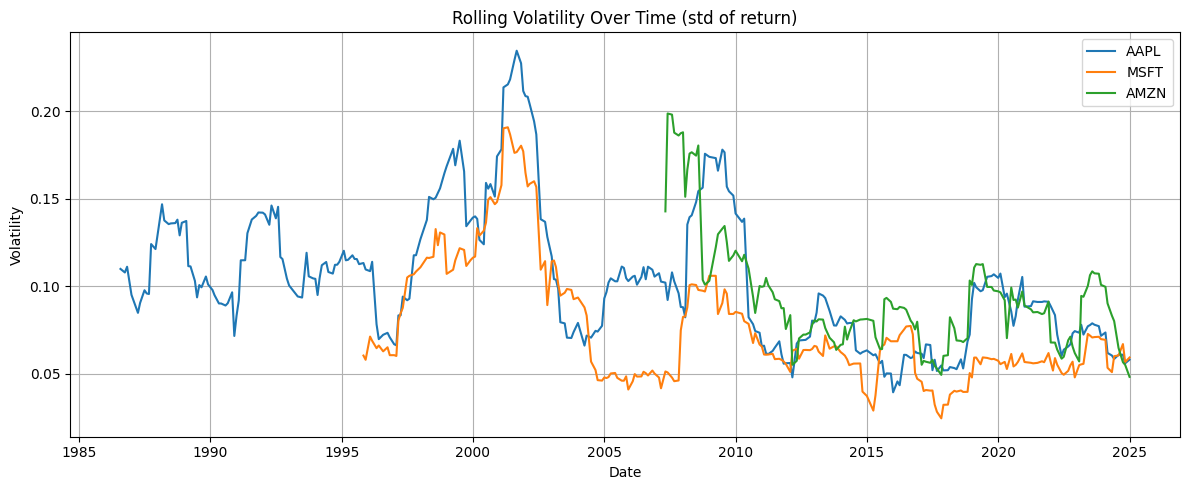

In [16]:
plt.figure(figsize=(12, 5))
for ticker in sample_tickers:
    if ticker in vol_df.columns:
        plt.plot(vol_df.index, vol_df[ticker], label=ticker)

plt.title("Rolling Volatility Over Time (std of return)")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


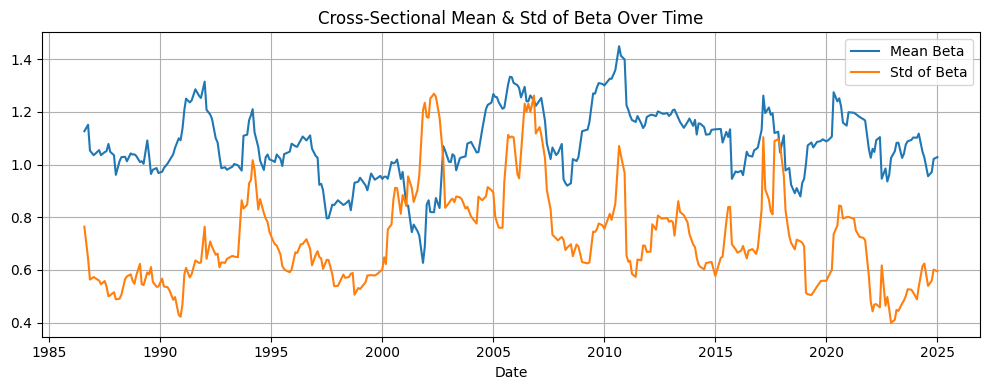

In [17]:

mean_beta = beta_df.mean(axis=1)
std_beta = beta_df.std(axis=1)

plt.figure(figsize=(10, 4))
plt.plot(mean_beta, label='Mean Beta')
plt.plot(std_beta, label='Std of Beta')
plt.title("Cross-Sectional Mean & Std of Beta Over Time")
plt.xlabel("Date")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [19]:
beta_df = beta_df.replace(0, np.nan)

w_raw = 1 / (beta_df * vol_df)

w_abs_sum = w_raw.abs().sum(axis=1)         
w_df = w_raw.div(w_abs_sum, axis=0)          

cap = 0.05
w_df = w_df.clip(lower=-cap, upper=cap)

w_df = w_df.div(w_df.abs().sum(axis=1), axis=0)

ret_panel = data.drop(columns='mkt_ret')
ret_panel = ret_panel.loc[w_df.index]        
port_ret = (w_df * ret_panel).sum(axis=1)    

combo_beta = (w_df * beta_df).sum(axis=1)

display(w_df.head())

print(combo_beta.describe())

,AMT,HON,AH,AMX,BEAM,PA,AMO,AR,AST,T,...,CSGP,TRGP,ACGL,STLD,GEHC,FICO,BG.1,PODD,AXON,PANW
1986-07-31,-0.006302,0.025720,0.000125,0.002154,0.000697,0.000821,0.000208,0.013832,0.000949,0.001294,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1986-09-30,0.003155,0.005108,0.000134,0.000971,0.001071,0.001514,0.000195,0.000683,0.000851,0.001457,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1986-10-31,0.001884,0.006655,0.000133,0.000983,0.000950,0.001259,0.000316,0.000744,0.001184,0.001325,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1986-12-31,0.001370,0.005325,0.000114,0.001048,0.000813,0.001326,0.000318,0.000534,0.001705,0.001481,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1987-03-31,0.001200,0.004188,0.000097,0.000845,0.000680,0.001160,0.000261,0.000480,0.001498,0.001281,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


count    324.000000
mean       0.423461
std        0.149639
min        0.079041
25%        0.314933
50%        0.422452
75%        0.527691
max        0.796349
dtype: float64


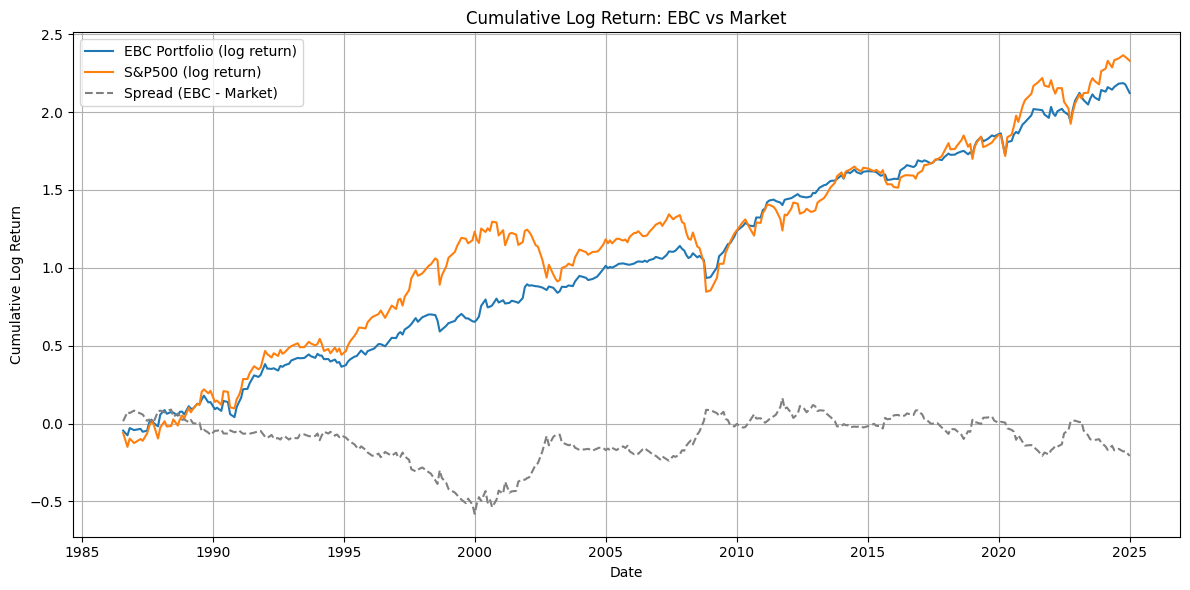

In [25]:
log_cum_port = np.log1p(port_ret).cumsum()
log_cum_mkt  = np.log1p(data.loc[port_ret.index, 'mkt_ret']).cumsum()
log_spread   = log_cum_port - log_cum_mkt

plt.figure(figsize=(12, 6))
plt.plot(log_cum_port, label="EBC Portfolio (log return)")
plt.plot(log_cum_mkt, label="S&P500 (log return)")
plt.plot(log_spread, label="Spread (EBC - Market)", linestyle='--', color='gray')
plt.title("Cumulative Log Return: EBC vs Market")
plt.ylabel("Cumulative Log Return")
plt.xlabel("Date")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


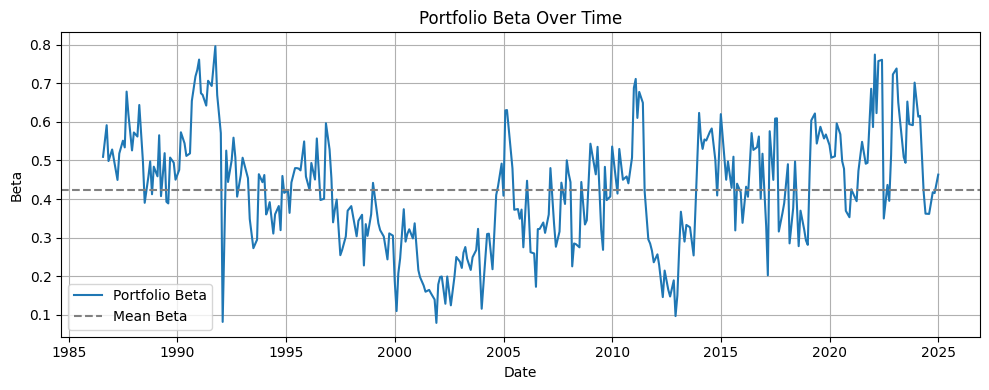

In [21]:
plt.figure(figsize=(10, 4))
plt.plot(combo_beta, label='Portfolio Beta')
plt.axhline(combo_beta.mean(), linestyle='--', color='gray', label='Mean Beta')
plt.title("Portfolio Beta Over Time")
plt.ylabel("Beta")
plt.xlabel("Date")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [22]:
ann_ret = (1 + port_ret).prod()**(12 / len(port_ret)) - 1
ann_vol = port_ret.std() * np.sqrt(12)
sharpe = ann_ret / ann_vol

print(f"Annualized Return: {ann_ret:.2%}")
print(f"Annualized Volatility: {ann_vol:.2%}")
print(f"Sharpe Ratio: {sharpe:.2f}")


Annualized Return: 8.18%
Annualized Volatility: 9.46%
Sharpe Ratio: 0.86


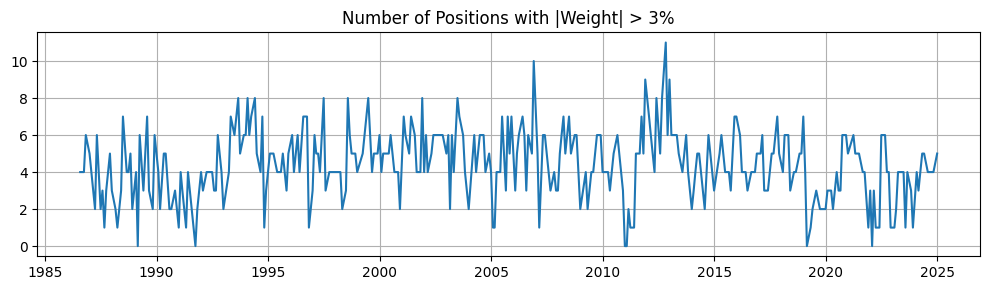

In [23]:
top_concentration = (w_df.abs() > 0.03).sum(axis=1)

plt.figure(figsize=(10, 3))
plt.plot(top_concentration)
plt.title("Number of Positions with |Weight| > 3%")
plt.grid(True)
plt.tight_layout()
plt.show()


In [26]:

def ebc_strategy_analysis(data, window=12, cap=0.05, plot=True):

    dates = data.index
    tickers = data.columns.drop("mkt_ret")
    beta_dict, vol_dict = {}, {}

    for i in range(window, len(dates)):
        current_date = dates[i]
        window_data = data.iloc[i-window:i]
        betas, volas = {}, {}

        for ticker in tickers:
            temp = window_data[[ticker, 'mkt_ret']].dropna()
            if len(temp) >= window:
                X = temp['mkt_ret'].values.reshape(-1, 1)
                y = temp[ticker].values
                beta = np.linalg.lstsq(X, y, rcond=None)[0][0]
                sigma = y.std()
                betas[ticker] = beta
                volas[ticker] = sigma

        beta_dict[current_date] = betas
        vol_dict[current_date] = volas

    beta_df = pd.DataFrame(beta_dict).T.sort_index()
    vol_df = pd.DataFrame(vol_dict).T.sort_index()

    
    w_raw = 1 / (beta_df * vol_df)
    w_abs_sum = w_raw.abs().sum(axis=1)
    w_df = w_raw.div(w_abs_sum, axis=0)

    
    w_df = w_df.clip(lower=-cap, upper=cap)
    w_df = w_df.div(w_df.abs().sum(axis=1), axis=0)

    
    ret_panel = data.drop(columns='mkt_ret').loc[w_df.index]
    port_ret = (w_df * ret_panel).sum(axis=1)
    combo_beta = (w_df * beta_df).sum(axis=1)

    
    if plot:
        log_cum_port = np.log1p(port_ret).cumsum()
        log_cum_mkt  = np.log1p(data.loc[port_ret.index, 'mkt_ret']).cumsum()
        log_spread   = log_cum_port - log_cum_mkt

        fig, axs = plt.subplots(3, 1, figsize=(12, 14))

        axs[0].plot(log_cum_port, label="EBC Portfolio (log return)")
        axs[0].plot(log_cum_mkt, label="S&P500 (log return)")
        axs[0].plot(log_spread, label="Spread (EBC - Market)", linestyle='--', color='gray')
        axs[0].set_title("Cumulative Log Return: EBC vs Market")
        axs[0].set_ylabel("Cumulative Log Return")
        axs[0].legend()
        axs[0].grid(True)

        axs[1].plot(combo_beta, label='Portfolio Beta')
        axs[1].axhline(combo_beta.mean(), linestyle='--', color='gray', label='Mean Beta')
        axs[1].set_title("Portfolio Beta Over Time")
        axs[1].set_ylabel("Beta")
        axs[1].legend()
        axs[1].grid(True)

        axs[2].plot(log_spread, label="Cumulative Log Return Spread", color='purple')
        axs[2].axhline(0, linestyle='--', color='gray')
        axs[2].set_title("Cumulative Log Return Spread (EBC - Market)")
        axs[2].set_ylabel("Log Return Spread")
        axs[2].legend()
        axs[2].grid(True)

        plt.tight_layout()
        plt.show()

    return port_ret, combo_beta, w_df


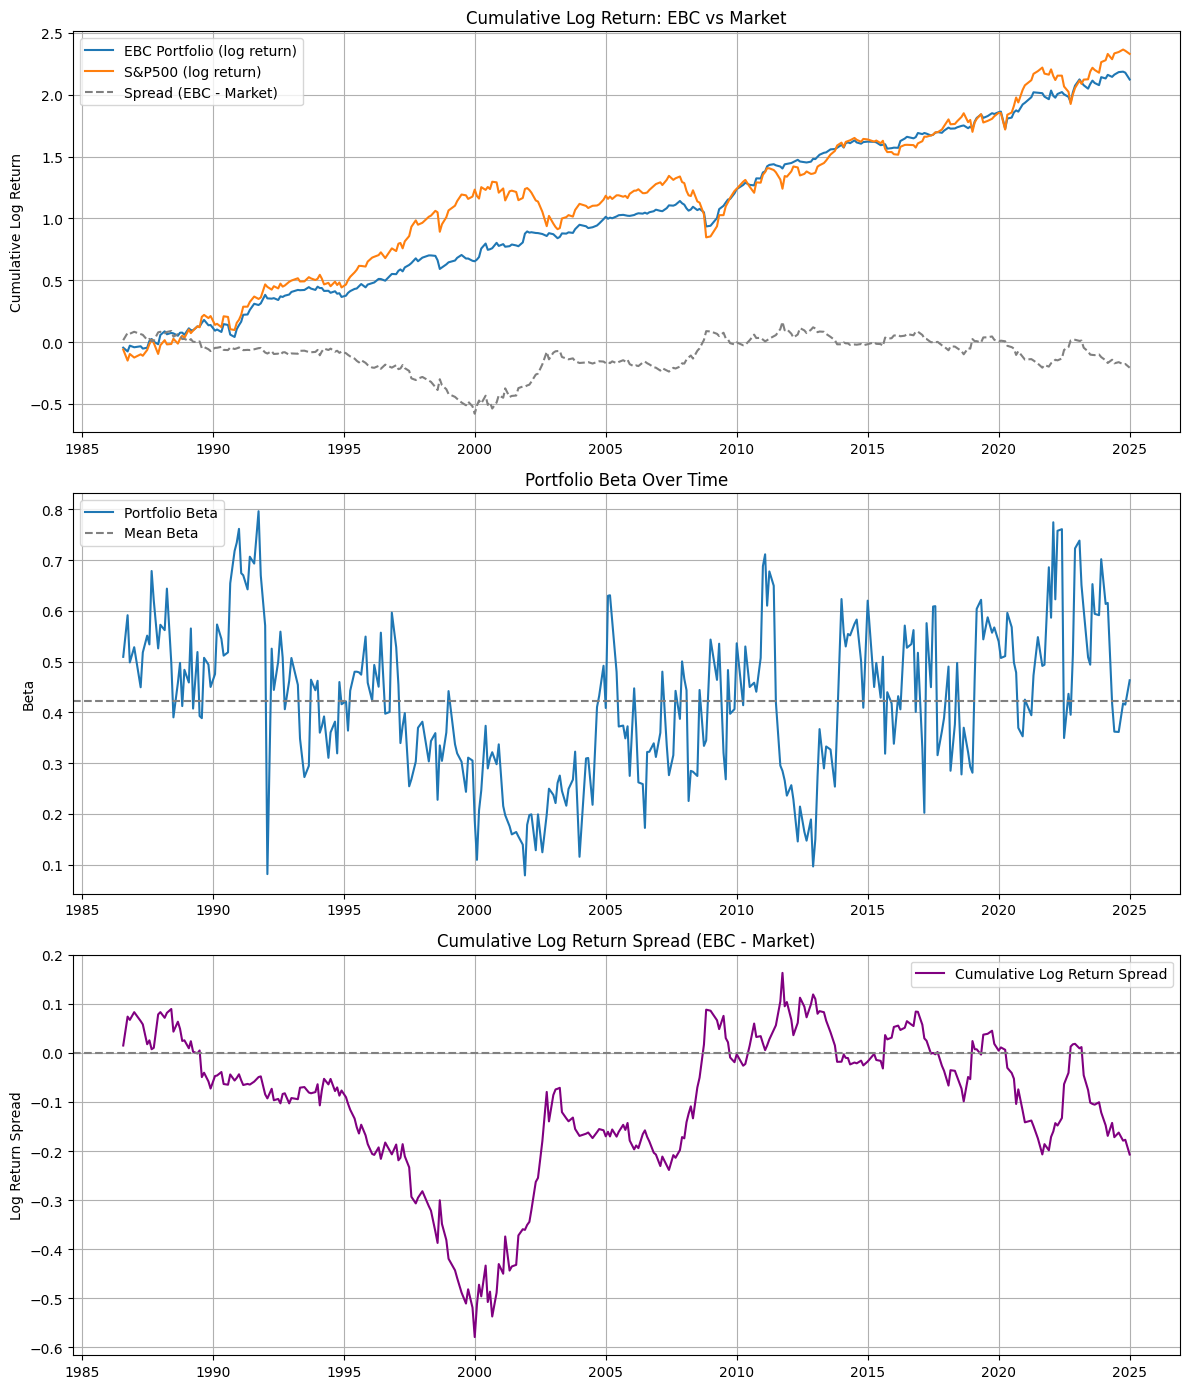

In [30]:
port_ret, combo_beta, w_df = ebc_strategy_analysis(data, window=12, cap=0.05)

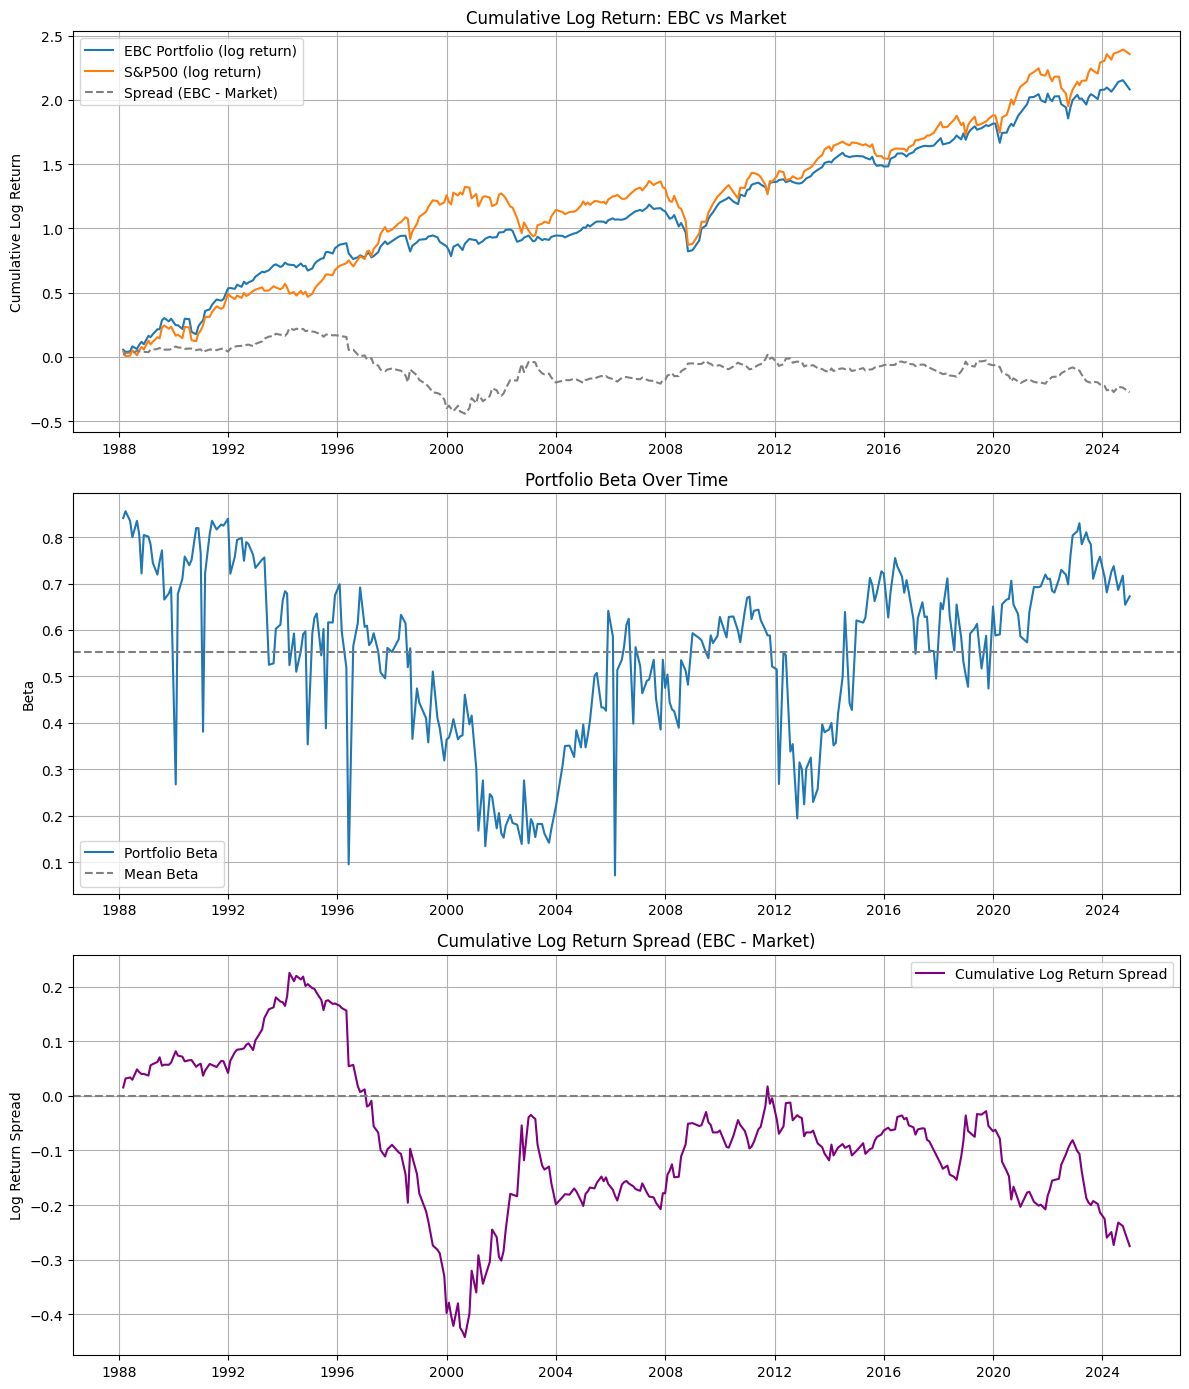

In [28]:
port_ret, combo_beta, w_df = ebc_strategy_analysis(data, window=24, cap=0.05)

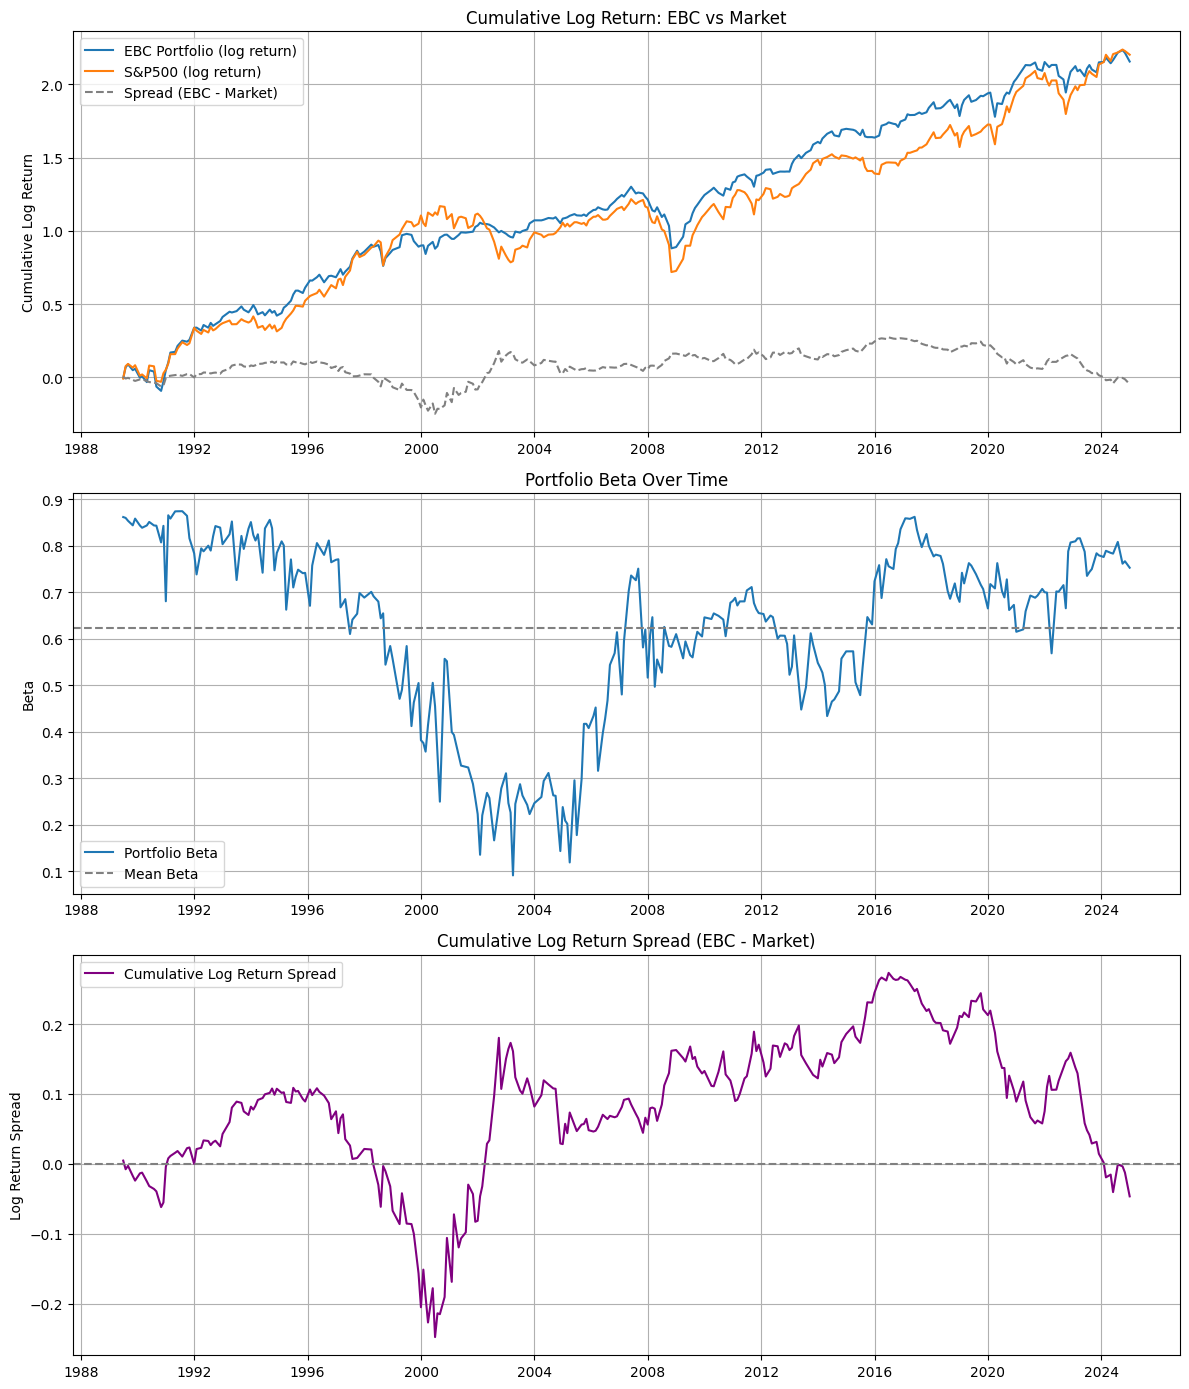

In [29]:
port_ret, combo_beta, w_df = ebc_strategy_analysis(data, window=36, cap=0.05)